# EDA Advan (mobility) data

This notebook contains several EDA plots for the advan mobility data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns

In [2]:
%%time
advan_df = pd.read_csv('../data/raw/mobility/advan/all_advan.csv', dtype={"cbsa_orig": str, "cbsa_dest": str})
safegraph_df = pd.read_csv('../data/raw/mobility/safegraph/all_harddrive_us.csv', dtype={"cbsa_orig": str, "cbsa_dest": str})


CPU times: user 1min 39s, sys: 34.1 s, total: 2min 13s
Wall time: 2min 15s


In [3]:
advan_df['date_range_start_str'] = pd.to_datetime(advan_df['date_range_start'], utc=True).dt.strftime('%Y-%m-%d')
advan_df['date_range_end_str'] = pd.to_datetime(advan_df['date_range_end'], utc=True).dt.strftime('%Y-%m-%d')

In [6]:
advan_dates = advan_df.drop_duplicates(subset=['date_range_start_str', 'date_range_end_str','date_range_start', 'date_range_end'])
advan_dates.groupby(['date_range_start_str', 'date_range_end_str']).size().sort_values(ascending=False)

date_range_start_str  date_range_end_str
2025-06-23            2025-06-30            7
2025-06-16            2025-06-23            7
2025-06-09            2025-06-16            7
2025-06-02            2025-06-09            7
2025-05-26            2025-06-02            7
                                           ..
2020-06-15            2020-06-22            6
2020-06-22            2020-06-29            6
2020-06-29            2020-07-06            6
2020-07-06            2020-07-13            6
2020-07-13            2020-07-20            6
Length: 286, dtype: int64

In [7]:
advan_dates.loc[advan_dates['date_range_start_str'] == '2025-06-23']

,date_range_start,date_range_end,cbsa_orig,cbsa_dest,visitor_home_aggregation,date_range_start_str,date_range_end_str
10421239,2025-06-23T00:00:00-04:00,2025-06-30T00:00:00-04:00,10180,41980,44,2025-06-23,2025-06-30
10421632,2025-06-23T00:00:00-05:00,2025-06-30T00:00:00-05:00,10100,10420,9,2025-06-23,2025-06-30
10479128,2025-06-23T00:00:00-06:00,2025-06-30T00:00:00-06:00,10100,10100,32058,2025-06-23,2025-06-30
10530213,2025-06-23T00:00:00-07:00,2025-06-30T00:00:00-07:00,10100,19740,7,2025-06-23,2025-06-30
10542578,2025-06-23T00:00:00-08:00,2025-06-30T00:00:00-08:00,10100,29820,505,2025-06-23,2025-06-30
10553058,2025-06-23T00:00:00-09:00,2025-06-30T00:00:00-09:00,10140,27940,63,2025-06-23,2025-06-30
10553791,2025-06-23T00:00:00-10:00,2025-06-30T00:00:00-10:00,10140,28180,441,2025-06-23,2025-06-30


In [ ]:
%%time

advan_groupby_df = advan_df.groupby(["cbsa_orig", "cbsa_dest", "date_range_start_str", "date_range_end_str"])['visitor_home_aggregation'].sum().reset_index()

(44490446, 5)
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/burg/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/IPython/core/magics/execution.py", line 1340, in time
    exec(code, glob, local_ns)
  File "<timed exec>", line 3, in <module>
  File "/burg/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/pandas/core/frame.py", line 6818, in drop_duplicates
    result = self[-self.duplicated(subset, keep=keep)]
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/burg/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/pandas/core/frame.py", line 6950, in duplicated
    raise KeyError(Index(diff))
KeyError: Index(['date_range_start', 'date_range_end'], dtype='object')

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/burg/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 2144, in showtraceback
    stb = self.InteractiveTB.structured

In [14]:
print(advan_groupby_df.shape)
print(advan_groupby_df.drop_duplicates(subset=["cbsa_orig", "cbsa_dest", "date_range_start", "date_range_end"]).shape)

advan_groupby_df.head()

(44490446, 5)
(44490446, 5)


,cbsa_orig,cbsa_dest,date_range_start,date_range_end,visitor_home_aggregation
0,10100,10100,2020-01-06,2020-01-13,151812
1,10100,10100,2020-01-13,2020-01-20,131991
2,10100,10100,2020-01-20,2020-01-27,147445
3,10100,10100,2020-01-27,2020-02-03,140151
4,10100,10100,2020-02-03,2020-02-10,155653


In [11]:
advan_groupby_df.rename(columns={'date_range_start_str': 'date_range_start', 'date_range_end_str': 'date_range_end'}, inplace=True)

In [15]:
advan_groupby_df.to_csv("all_advan_fix.csv", index=False)

## 1. Safegraph vs Advan Scatter plot

In [16]:
print(advan_groupby_df.date_range_end.max())
print(safegraph_df.date_range_end.max())

2025-06-30
2023-01-02


Check that both are unique by cbsa X date

In [17]:
print(advan_groupby_df.shape)
print(safegraph_df.shape)

(44490446, 5)
(26485695, 12)


In [18]:
print(advan_groupby_df.shape)
advan_groupby_df.drop_duplicates(subset=["cbsa_orig", "cbsa_dest", "date_range_start", "date_range_end"]).shape

(44490446, 5)


(44490446, 5)

In [19]:
%%time
# Convert date columns to YYYY-MM-DD strings for consistent merging
# advan_df['date_range_start'] = pd.to_datetime(advan_df['date_range_start'], utc=True).dt.strftime('%Y-%m-%d')
# advan_df['date_range_end'] = pd.to_datetime(advan_df['date_range_end'], utc=True).dt.strftime('%Y-%m-%d')
safegraph_df['date_range_start'] = pd.to_datetime(safegraph_df['date_range_start']).dt.strftime('%Y-%m-%d')
safegraph_df['date_range_end'] = pd.to_datetime(safegraph_df['date_range_end']).dt.strftime('%Y-%m-%d')

# Ensure cbsa columns are strings for consistent merging
advan_groupby_df['cbsa_orig'] = advan_groupby_df['cbsa_orig'].astype(str)
advan_groupby_df['cbsa_dest'] = advan_groupby_df['cbsa_dest'].astype(str)
safegraph_df['cbsa_orig'] = safegraph_df['cbsa_orig'].astype(str)
safegraph_df['cbsa_dest'] = safegraph_df['cbsa_dest'].astype(str)

# Merge on the specified columns
merged_df = advan_groupby_df.merge(
    safegraph_df,
    on=['date_range_start', 'date_range_end', 'cbsa_orig', 'cbsa_dest'],
    suffixes=('_advan', '_safegraph'),
    how='inner'
)

print(f"\nMerged dataframe shape: {merged_df.shape}")
print(f"Number of matching records: {len(merged_df)}")


Merged dataframe shape: (13941562, 13)
Number of matching records: 13941562
CPU times: user 1min 6s, sys: 35.1 s, total: 1min 41s
Wall time: 1min 45s


In [20]:
merged_df.to_csv("advan_safegraph_scatter.csv", index=False)
# merged_df = pd.read_csv("advan_safegraph_scatter.csv")

In [21]:
merged_df.date_range_end.nunique()

156

In [22]:
print(merged_df.cbsa_orig.nunique(), merged_df.cbsa_dest.nunique())

918 927


In [23]:
print(merged_df["date_range_start"].min())
print(merged_df["date_range_start"].max())
print(merged_df["date_range_start"].nunique())

2020-01-06
2022-12-26
156


In [24]:
merged_df_2022 = merged_df.loc[pd.to_datetime(merged_df["date_range_start"]).dt.year == 2022]

In [25]:
merged_df_2022.shape

(5234632, 13)

In [26]:
# Create scatter plot
def plot_scatter(merged_df, color_month=False):
    plt.figure(figsize=(10, 8))

    merged_df["date_range_start"] = pd.to_datetime(merged_df["date_range_start"])

    if color_month:
        for m in range(12):
            plt.scatter(
                merged_df.loc[merged_df["date_range_start"].dt.month == m, 'visitor_home_aggregation_advan'],
                merged_df.loc[merged_df["date_range_start"].dt.month == m, 'visitor_home_aggregation_safegraph'],
                alpha=0.5,
                s=10,
                label=m,
            )
    else:
        plt.scatter(
            merged_df['visitor_home_aggregation_advan'],
            merged_df['visitor_home_aggregation_safegraph'],
            alpha=0.5,
            s=10,
        )
    plt.xlabel('Advan visitor_home_aggregation', fontsize=12)
    plt.ylabel('Safegraph visitor_home_aggregation', fontsize=12)
    plt.title('Scatter Plot: Advan vs Safegraph visitor_home_aggregation', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Add diagonal line for reference
    max_val = max(
        merged_df['visitor_home_aggregation_advan'].max(),
        merged_df['visitor_home_aggregation_safegraph'].max()
    )
    min_val = min(
        merged_df['visitor_home_aggregation_advan'].min(),
        merged_df['visitor_home_aggregation_safegraph'].min()
    )
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
    plt.legend()
    
    # Use log scale if data spans large range
    if max_val / min_val > 100:
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Advan visitor_home_aggregation (log scale)', fontsize=12)
        plt.ylabel('Safegraph visitor_home_aggregation (log scale)', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print correlation
    correlation = merged_df['visitor_home_aggregation_advan'].corr(
        merged_df['visitor_home_aggregation_safegraph']
    )
    print(f"\nCorrelation: {correlation:.4f}")


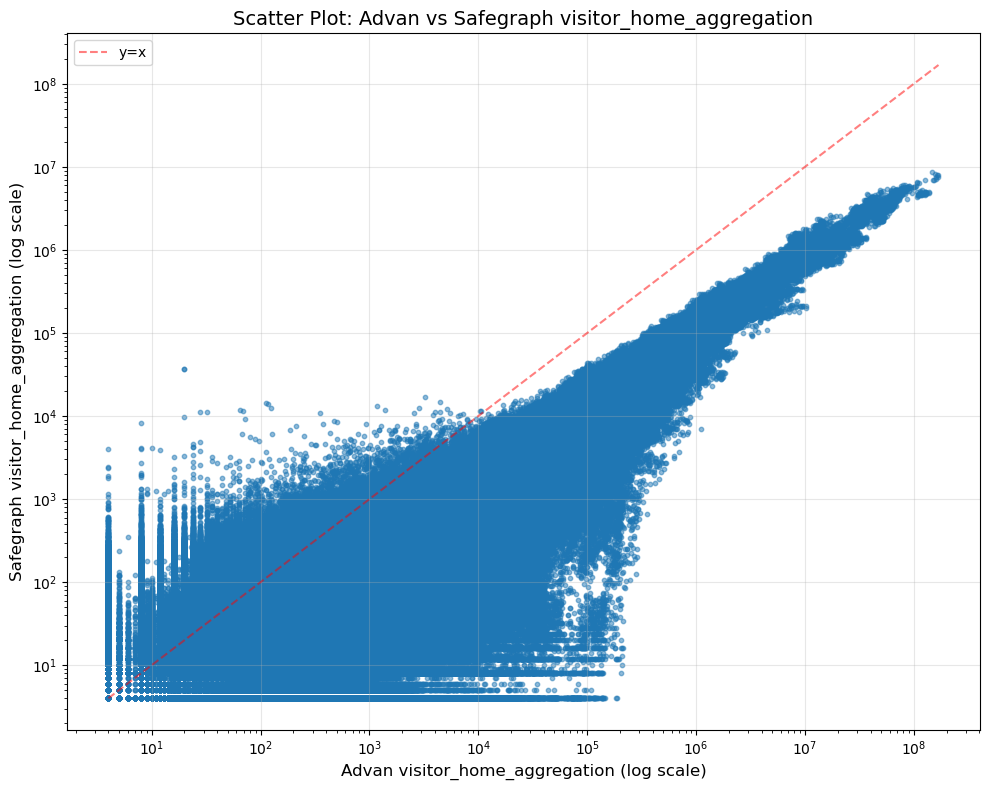


Correlation: 0.9530
CPU times: user 1min 33s, sys: 10.9 s, total: 1min 44s
Wall time: 1min 44s


In [27]:
%%time
plot_scatter(merged_df)

/local/ipykernel_269295/252532751.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df["date_range_start"] = pd.to_datetime(merged_df["date_range_start"])


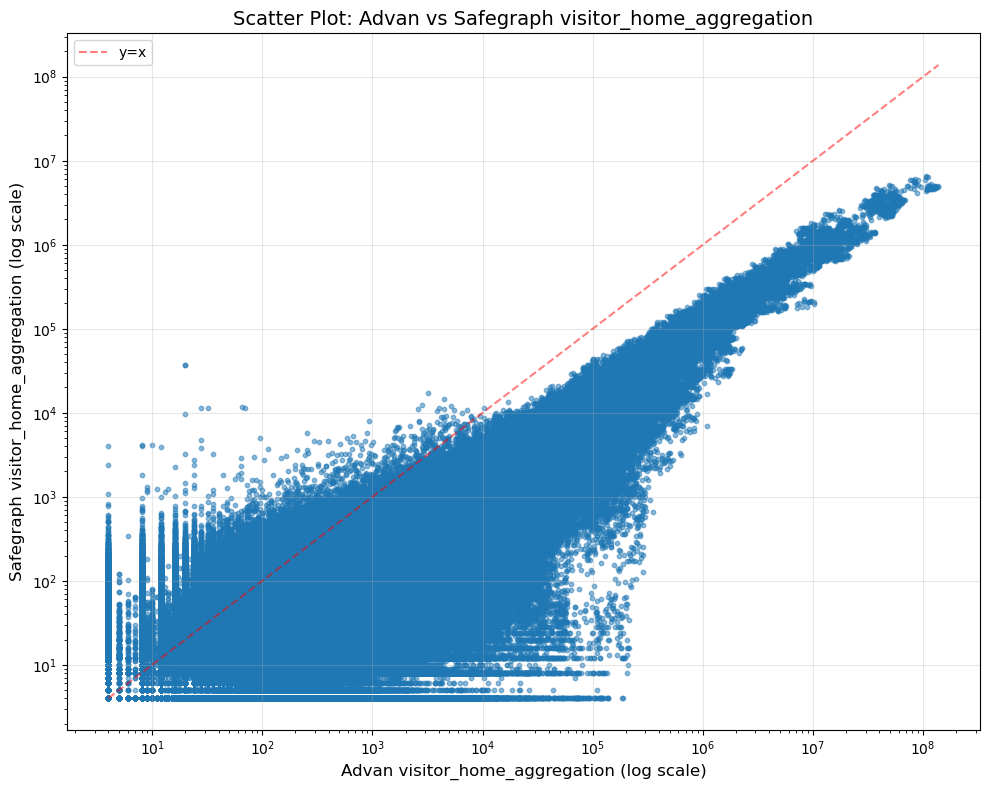


Correlation: 0.9409
CPU times: user 34.5 s, sys: 3.49 s, total: 38 s
Wall time: 37.7 s


In [28]:
%%time
plot_scatter(merged_df_2022)

In [29]:
merged_df_2022["ratio"] = merged_df_2022["visitor_home_aggregation_advan"] / merged_df_2022["visitor_home_aggregation_safegraph"]

/local/ipykernel_269295/1582435331.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_2022["ratio"] = merged_df_2022["visitor_home_aggregation_advan"] / merged_df_2022["visitor_home_aggregation_safegraph"]


In [30]:
merged_df_2022["ratio"].describe()

count    5.234632e+06
mean     1.179921e+01
std      1.111881e+02
min      5.420936e-04
25%      1.954545e+00
50%      4.412698e+00
75%      1.000000e+01
max      4.703875e+04
Name: ratio, dtype: float64

In [31]:
merged_df_2022.loc[merged_df_2022["ratio"] > 100].groupby(["cbsa_orig", "cbsa_dest"])["date_range_start"].count().sort_values(ascending=False)

cbsa_orig  cbsa_dest
42660      28540        49
27140      35020        48
25420      44420        48
20700      30140        48
10900      44420        48
                        ..
26090      42660         1
           42340         1
           41860         1
           40900         1
26140      12020         1
Name: date_range_start, Length: 27007, dtype: int64

In [32]:
merged_df_2022.shape

(5234632, 14)

In [33]:
merged_df_2022.groupby(["cbsa_orig", "cbsa_dest", "date_range_start", "date_range_end"])[["visitor_home_aggregation_advan", "visitor_home_aggregation_safegraph"]].sum()

visitor_home_aggregation_advan  \
cbsa_orig cbsa_dest date_range_start date_range_end                                   
10100     10100     2022-01-03       2022-01-10                              137622   
                    2022-01-10       2022-01-17                              132718   
                    2022-01-17       2022-01-24                              130071   
                    2022-01-24       2022-01-31                              133348   
                    2022-01-31       2022-02-07                              140957   
...                                                                             ...   
49820     49820     2022-11-28       2022-12-05                               23327   
                    2022-12-05       2022-12-12                               22579   
                    2022-12-12       2022-12-19                               21826   
                    2022-12-19       2022-12-26                               19722   
                    2022-12-26       2023-01-02                               16608   

                                                     visitor_home_aggregation_safegraph  
cbsa_orig cbsa_dest date_range_start date_range_end                                      
10100     10100     2022-01-03       2022-01-10                                   12698  
                    2022-01-10       2022-01-17                                   13544  
                    2022-01-17       2022-01-24                                   12670  
                    2022-01-24       2022-01-31                                   13065  
                    2022-01-31       2022-02-07                                   13294  
...                                                                                 ...  
49820     49820     2022-11-28       2022-12-05                                    6017  
                    2022-12-05       2022-12-12                                    5952  
                    2022-12-12       2022-12-19                                    6122  
                    2022-12-19       2022-12-26                                    5950  
                    2022-12-26       2023-01-02                                    4439  

[5234632 rows x 2 columns]

In [34]:
merged_df_2022.groupby(["cbsa_orig", "cbsa_dest"])["date_range_start"].count().sort_values(ascending=False)

cbsa_orig  cbsa_dest
49820      29700        52
10100      13900        52
49820      49820        52
10100      10100        52
26090      27100        52
                        ..
49820      29180         1
           29380         1
           29740         1
           30420         1
           30980         1
Name: date_range_start, Length: 406875, dtype: int64

In [35]:
merged_df_2022.loc[merged_df_2022["ratio"] < 0.01].groupby(["cbsa_orig", "cbsa_dest"])["date_range_start"].count().sort_values(ascending=False)

cbsa_orig  cbsa_dest
14710      14710        6
40860      40860        5
28300      14710        4
26740      12060        3
21340      41620        3
41620      21340        2
15540      15540        2
47900      41980        2
10740      41620        1
21780      18020        1
16100      38060        1
30780      19740        1
25940      35620        1
17780      21340        1
33340      36420        1
37980      41980        1
36740      41980        1
41140      19740        1
45300      41980        1
Name: date_range_start, dtype: int64

In [36]:
merged_df_2022.shape

(5234632, 14)

In [ ]:
import seaborn as sns

# Define x and y for clarity
x_data = merged_df_2022['visitor_home_aggregation_advan']
y_data = merged_df_2022['visitor_home_aggregation_safegraph']

# Create density plot
plt.figure(figsize=(12, 8))

# *** Determine if log scale should be used, based on original logic ***
# Ensure min values are positive for log scale
min_x = max(min(x_data), 1e-1)
min_y = max(min(y_data), 1e-1)
use_log_scale = (x_data.max() / min_x > 100) or (y_data.max() / min_y > 100)

sns.kdeplot(
    x=x_data,
    y=y_data,
    fill=True,
    cmap='viridis',
    cbar=True,
    log_scale=use_log_scale
)

# *** Set labels, updating them if log scale was used ***
if use_log_scale:
    plt.xlabel('Advan visitor_home_aggregation (log scale)', fontsize=12)
    plt.ylabel('Safegraph visitor_home_aggregation (log scale)', fontsize=12)
else:
    plt.xlabel('Advan visitor_home_aggregation', fontsize=12)
    plt.ylabel('Safegraph visitor_home_aggregation', fontsize=12)

plt.title('KDE Plot: Advan vs Safegraph visitor_home_aggregation', fontsize=14)
plt.grid(True, alpha=0.3, linestyle=':')

# Add diagonal line for reference
# Ensure min_val is positive for log scale compatibility
min_val = max(
    min(x_data.min(), y_data.min()),
    1e-1  # Use a small positive number if min is zero or negative
)
max_val = max(
    x_data.max(),
    y_data.max()
)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='y=x')

# *** Set plot limits AFTER plotting, especially important for log scale ***
if use_log_scale:
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)

plt.legend()  # Call legend after potential scale change to ensure it's placed well
plt.tight_layout()
plt.show()


plt.savefig('advan_vs_safegraph.png')


In [ ]:
# Enhanced scatter plots to investigate patterns in advan vs safegraph differences

def plot_scatter_by_time(merged_df, year=2022):
    """Scatter plot colored by month to check if outliers vary by time"""
    df = merged_df.loc[pd.to_datetime(merged_df["date_range_start"]).dt.year == year].copy()
    df["date_range_start"] = pd.to_datetime(df["date_range_start"])
    df["month"] = df["date_range_start"].dt.month
    
    plt.figure(figsize=(12, 10))
    
    scatter = plt.scatter(
        df['visitor_home_aggregation_advan'],
        df['visitor_home_aggregation_safegraph'],
        c=df['month'],
        cmap='tab20',
        alpha=0.6,
        s=20,
        edgecolors='black',
        linewidths=0.1
    )
    
    plt.colorbar(scatter, label='Month')
    plt.xlabel('Advan visitor_home_aggregation', fontsize=12)
    plt.ylabel('Safegraph visitor_home_aggregation', fontsize=12)
    plt.title(f'Scatter Plot by Month (Year {year}): Advan vs Safegraph', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Add diagonal line
    max_val = max(
        df['visitor_home_aggregation_advan'].max(),
        df['visitor_home_aggregation_safegraph'].max()
    )
    min_val = max(
        min(df['visitor_home_aggregation_advan'].min(), df['visitor_home_aggregation_safegraph'].min()),
        1e-1
    )
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
    
    # Use log scale if needed
    if max_val / min_val > 100:
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Advan visitor_home_aggregation (log scale)', fontsize=12)
        plt.ylabel('Safegraph visitor_home_aggregation (log scale)', fontsize=12)
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Print correlation by month
    print("\nCorrelation by month:")
    for month in sorted(df['month'].unique()):
        month_df = df[df['month'] == month]
        corr = month_df['visitor_home_aggregation_advan'].corr(
            month_df['visitor_home_aggregation_safegraph']
        )
        print(f"  Month {int(month)}: {corr:.4f}")



In [ ]:
def plot_scatter_by_cbsa_pair(merged_df, year=2022, top_n=20):
    """Scatter plot highlighting top outlier cbsa_orig X cbsa_dest pairs"""
    df = merged_df.loc[pd.to_datetime(merged_df["date_range_start"]).dt.year == year].copy()
    df["date_range_start"] = pd.to_datetime(df["date_range_start"])
    df["ratio"] = df["visitor_home_aggregation_advan"] / df["visitor_home_aggregation_safegraph"]
    df["cbsa_pair"] = df["cbsa_orig"] + " -> " + df["cbsa_dest"]
    
    # Identify top outlier pairs (high and low ratios)
    high_ratio_pairs = df.loc[df["ratio"] > 100].groupby("cbsa_pair")["ratio"].count().sort_values(ascending=False).head(top_n).index
    low_ratio_pairs = df.loc[df["ratio"] < 0.01].groupby("cbsa_pair")["ratio"].count().sort_values(ascending=False).head(top_n).index
    
    plt.figure(figsize=(14, 10))
    
    # Plot all points in gray
    plt.scatter(
        df['visitor_home_aggregation_advan'],
        df['visitor_home_aggregation_safegraph'],
        c='lightgray',
        alpha=0.3,
        s=10,
        label='Other pairs'
    )
    
    # Highlight high ratio pairs (advan >> safegraph)
    if len(high_ratio_pairs) > 0:
        high_df = df[df["cbsa_pair"].isin(high_ratio_pairs)]
        plt.scatter(
            high_df['visitor_home_aggregation_advan'],
            high_df['visitor_home_aggregation_safegraph'],
            c='red',
            alpha=0.7,
            s=50,
            edgecolors='darkred',
            linewidths=0.5,
            label=f'High ratio pairs (ratio > 100, top {len(high_ratio_pairs)})'
        )
    
    # Highlight low ratio pairs (safegraph >> advan)
    if len(low_ratio_pairs) > 0:
        low_df = df[df["cbsa_pair"].isin(low_ratio_pairs)]
        plt.scatter(
            low_df['visitor_home_aggregation_advan'],
            low_df['visitor_home_aggregation_safegraph'],
            c='blue',
            alpha=0.7,
            s=50,
            edgecolors='darkblue',
            linewidths=0.5,
            label=f'Low ratio pairs (ratio < 0.01, top {len(low_ratio_pairs)})'
        )
    
    plt.xlabel('Advan visitor_home_aggregation', fontsize=12)
    plt.ylabel('Safegraph visitor_home_aggregation', fontsize=12)
    plt.title(f'Scatter Plot Highlighting Outlier CBSA Pairs (Year {year})', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Add diagonal line
    max_val = max(
        df['visitor_home_aggregation_advan'].max(),
        df['visitor_home_aggregation_safegraph'].max()
    )
    min_val = max(
        min(df['visitor_home_aggregation_advan'].min(), df['visitor_home_aggregation_safegraph'].min()),
        1e-1
    )
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
    
    # Use log scale if needed
    if max_val / min_val > 100:
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Advan visitor_home_aggregation (log scale)', fontsize=12)
        plt.ylabel('Safegraph visitor_home_aggregation (log scale)', fontsize=12)
    
    plt.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Print top outlier pairs
    print("\nTop high ratio pairs (advan >> safegraph):")
    for pair in high_ratio_pairs[:10]:
        pair_df = df[df["cbsa_pair"] == pair]
        print(f"  {pair}: {len(pair_df)} records, mean ratio: {pair_df['ratio'].mean():.2f}")
    
    print("\nTop low ratio pairs (safegraph >> advan):")
    for pair in low_ratio_pairs[:10]:
        pair_df = df[df["cbsa_pair"] == pair]
        print(f"  {pair}: {len(pair_df)} records, mean ratio: {pair_df['ratio'].mean():.4f}")



In [ ]:
def plot_ratio_heatmap_by_cbsa(merged_df, year=2022, top_n=30):
    """Heatmap showing ratio patterns by cbsa_orig X cbsa_dest"""
    df = merged_df.loc[pd.to_datetime(merged_df["date_range_start"]).dt.year == year].copy()
    df["ratio"] = df["visitor_home_aggregation_advan"] / df["visitor_home_aggregation_safegraph"]
    
    # Get top N most frequent cbsa pairs (by count of records)
    top_pairs = df.groupby(["cbsa_orig", "cbsa_dest"]).size().sort_values(ascending=False).head(top_n)
    top_orig = top_pairs.index.get_level_values(0).unique()[:top_n]
    top_dest = top_pairs.index.get_level_values(1).unique()[:top_n]
    
    # Create pivot table for heatmap
    pivot_data = df[df["cbsa_orig"].isin(top_orig) & df["cbsa_dest"].isin(top_dest)].groupby(
        ["cbsa_orig", "cbsa_dest"]
    )["ratio"].mean().reset_index()
    
    pivot_table = pivot_data.pivot(index="cbsa_orig", columns="cbsa_dest", values="ratio")
    
    plt.figure(figsize=(16, 12))
    sns.heatmap(
        pivot_table,
        cmap='RdYlBu_r',
        center=1.0,
        vmin=0.1,
        vmax=10,
        cbar_kws={'label': 'Mean Ratio (Advan/Safegraph)'},
        square=False,
        linewidths=0.1
    )
    plt.title(f'Heatmap: Mean Ratio by CBSA Origin X Destination (Year {year}, Top {top_n} pairs)', fontsize=14)
    plt.xlabel('CBSA Destination', fontsize=10)
    plt.ylabel('CBSA Origin', fontsize=10)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()



In [ ]:
def plot_ratio_distribution_by_dimension(merged_df, year=2022):
    """Plot ratio distributions across different dimensions"""
    df = merged_df.loc[pd.to_datetime(merged_df["date_range_start"]).dt.year == year].copy()
    df["date_range_start"] = pd.to_datetime(df["date_range_start"])
    df["ratio"] = df["visitor_home_aggregation_advan"] / df["visitor_home_aggregation_safegraph"]
    df["month"] = df["date_range_start"].dt.month
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Ratio distribution by month
    ax1 = axes[0, 0]
    for month in sorted(df['month'].unique()):
        month_data = df[df['month'] == month]['ratio']
        ax1.hist(month_data, bins=50, alpha=0.5, label=f'Month {int(month)}', density=True)
    ax1.set_xlabel('Ratio (Advan/Safegraph)', fontsize=10)
    ax1.set_ylabel('Density', fontsize=10)
    ax1.set_title('Ratio Distribution by Month', fontsize=12)
    ax1.set_xscale('log')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Box plot of ratio by month
    ax2 = axes[0, 1]
    df.boxplot(column='ratio', by='month', ax=ax2)
    ax2.set_xlabel('Month', fontsize=10)
    ax2.set_ylabel('Ratio (Advan/Safegraph, log scale)', fontsize=10)
    ax2.set_title('Ratio Distribution by Month (Box Plot)', fontsize=12)
    plt.suptitle('')  # Remove default title
    ax2.grid(True, alpha=0.3)
    
    # 3. Ratio vs absolute values (to see if outliers are in specific value ranges)
    ax3 = axes[1, 0]
    scatter = ax3.scatter(
        df['visitor_home_aggregation_advan'],
        df['ratio'],
        c=df['month'],
        cmap='tab20',
        alpha=0.5,
        s=10
    )
    ax3.set_xlabel('Advan visitor_home_aggregation', fontsize=10)
    ax3.set_ylabel('Ratio (Advan/Safegraph)', fontsize=10)
    ax3.set_title('Ratio vs Advan Value (colored by month)', fontsize=12)
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    plt.colorbar(scatter, ax=ax3, label='Month')
    ax3.grid(True, alpha=0.3)
    
    # 4. Ratio vs absolute values (safegraph)
    ax4 = axes[1, 1]
    scatter = ax4.scatter(
        df['visitor_home_aggregation_safegraph'],
        df['ratio'],
        c=df['month'],
        cmap='tab20',
        alpha=0.5,
        s=10
    )
    ax4.set_xlabel('Safegraph visitor_home_aggregation', fontsize=10)
    ax4.set_ylabel('Ratio (Advan/Safegraph)', fontsize=10)
    ax4.set_title('Ratio vs Safegraph Value (colored by month)', fontsize=12)
    ax4.set_xscale('log')
    ax4.set_yscale('log')
    plt.colorbar(scatter, ax=ax4, label='Month')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nRatio statistics by month:")
    print(df.groupby('month')['ratio'].describe())



In [ ]:
def plot_outlier_analysis(merged_df, year=2022):
    """Comprehensive analysis of outliers with multiple visualizations"""
    df = merged_df.loc[pd.to_datetime(merged_df["date_range_start"]).dt.year == year].copy()
    df["date_range_start"] = pd.to_datetime(df["date_range_start"])
    df["ratio"] = df["visitor_home_aggregation_advan"] / df["visitor_home_aggregation_safegraph"]
    df["month"] = df["date_range_start"].dt.month
    df["cbsa_pair"] = df["cbsa_orig"] + " -> " + df["cbsa_dest"]
    
    # Define outliers
    df["is_high_outlier"] = df["ratio"] > 100
    df["is_low_outlier"] = df["ratio"] < 0.01
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # 1. Outlier count by month
    ax1 = axes[0, 0]
    outlier_by_month = df.groupby('month').agg({
        'is_high_outlier': 'sum',
        'is_low_outlier': 'sum'
    })
    x = range(len(outlier_by_month))
    width = 0.35
    ax1.bar([i - width/2 for i in x], outlier_by_month['is_high_outlier'], width, 
            label='High outliers (ratio > 100)', color='red', alpha=0.7)
    ax1.bar([i + width/2 for i in x], outlier_by_month['is_low_outlier'], width,
            label='Low outliers (ratio < 0.01)', color='blue', alpha=0.7)
    ax1.set_xlabel('Month', fontsize=10)
    ax1.set_ylabel('Count of Outliers', fontsize=10)
    ax1.set_title('Outlier Count by Month', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels([int(m) for m in sorted(df['month'].unique())])
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 2. Top outlier cbsa pairs (high)
    ax2 = axes[0, 1]
    top_high_pairs = df[df['is_high_outlier']].groupby('cbsa_pair').size().sort_values(ascending=False).head(15)
    ax2.barh(range(len(top_high_pairs)), top_high_pairs.values)
    ax2.set_yticks(range(len(top_high_pairs)))
    ax2.set_yticklabels([pair[:40] + '...' if len(pair) > 40 else pair for pair in top_high_pairs.index], fontsize=8)
    ax2.set_xlabel('Count of High Outliers', fontsize=10)
    ax2.set_title('Top 15 CBSA Pairs with High Outliers (ratio > 100)', fontsize=12)
    ax2.grid(True, alpha=0.3, axis='x')
    
    # 3. Top outlier cbsa pairs (low)
    ax3 = axes[0, 2]
    top_low_pairs = df[df['is_low_outlier']].groupby('cbsa_pair').size().sort_values(ascending=False).head(15)
    ax3.barh(range(len(top_low_pairs)), top_low_pairs.values)
    ax3.set_yticks(range(len(top_low_pairs)))
    ax3.set_yticklabels([pair[:40] + '...' if len(pair) > 40 else pair for pair in top_low_pairs.index], fontsize=8)
    ax3.set_xlabel('Count of Low Outliers', fontsize=10)
    ax3.set_title('Top 15 CBSA Pairs with Low Outliers (ratio < 0.01)', fontsize=12)
    ax3.grid(True, alpha=0.3, axis='x')
    
    # 4. Scatter with outlier highlighting
    ax4 = axes[1, 0]
    # Normal points
    normal_df = df[~df['is_high_outlier'] & ~df['is_low_outlier']]
    ax4.scatter(normal_df['visitor_home_aggregation_advan'], 
                normal_df['visitor_home_aggregation_safegraph'],
                c='gray', alpha=0.3, s=5, label='Normal')
    # High outliers
    high_df = df[df['is_high_outlier']]
    if len(high_df) > 0:
        ax4.scatter(high_df['visitor_home_aggregation_advan'],
                    high_df['visitor_home_aggregation_safegraph'],
                    c='red', alpha=0.7, s=30, label=f'High outliers ({len(high_df)})')
    # Low outliers
    low_df = df[df['is_low_outlier']]
    if len(low_df) > 0:
        ax4.scatter(low_df['visitor_home_aggregation_advan'],
                    low_df['visitor_home_aggregation_safegraph'],
                    c='blue', alpha=0.7, s=30, label=f'Low outliers ({len(low_df)})')
    ax4.set_xlabel('Advan visitor_home_aggregation', fontsize=10)
    ax4.set_ylabel('Safegraph visitor_home_aggregation', fontsize=10)
    ax4.set_title('Scatter Plot with Outlier Highlighting', fontsize=12)
    ax4.set_xscale('log')
    ax4.set_yscale('log')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # 5. Ratio distribution (log scale)
    ax5 = axes[1, 1]
    ax5.hist(df['ratio'], bins=1000, alpha=0.7, edgecolor='black')
    ax5.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Ratio = 1')
    ax5.set_xlabel('Ratio (Advan/Safegraph)', fontsize=10)
    ax5.set_ylabel('Frequency', fontsize=10)
    ax5.set_title('Ratio Distribution (All Data)', fontsize=12)
    ax5.set_xscale('log')
    ax5.legend()
    ax5.grid(True, alpha=0.3, axis='y')
    
    # 6. Outlier percentage by cbsa_orig
    ax6 = axes[1, 2]
    top_orig = df['cbsa_orig'].value_counts().head(20).index
    orig_outlier_pct = df[df['cbsa_orig'].isin(top_orig)].groupby('cbsa_orig').apply(
        lambda x: (x['is_high_outlier'].sum() + x['is_low_outlier'].sum()) / len(x) * 100
    ).sort_values(ascending=False)
    ax6.barh(range(len(orig_outlier_pct)), orig_outlier_pct.values)
    ax6.set_yticks(range(len(orig_outlier_pct)))
    ax6.set_yticklabels([str(orig)[:30] + '...' if len(str(orig)) > 30 else str(orig) 
                         for orig in orig_outlier_pct.index], fontsize=8)
    ax6.set_xlabel('Outlier Percentage (%)', fontsize=10)
    ax6.set_title('Top 20 CBSA Origins by Outlier Percentage', fontsize=12)
    ax6.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\nOutlier Summary (Year {year}):")
    print(f"  Total records: {len(df)}")
    print(f"  High outliers (ratio > 100): {df['is_high_outlier'].sum()} ({df['is_high_outlier'].sum()/len(df)*100:.2f}%)")
    print(f"  Low outliers (ratio < 0.01): {df['is_low_outlier'].sum()} ({df['is_low_outlier'].sum()/len(df)*100:.2f}%)")
    print(f"  Normal records: {(~df['is_high_outlier'] & ~df['is_low_outlier']).sum()}")



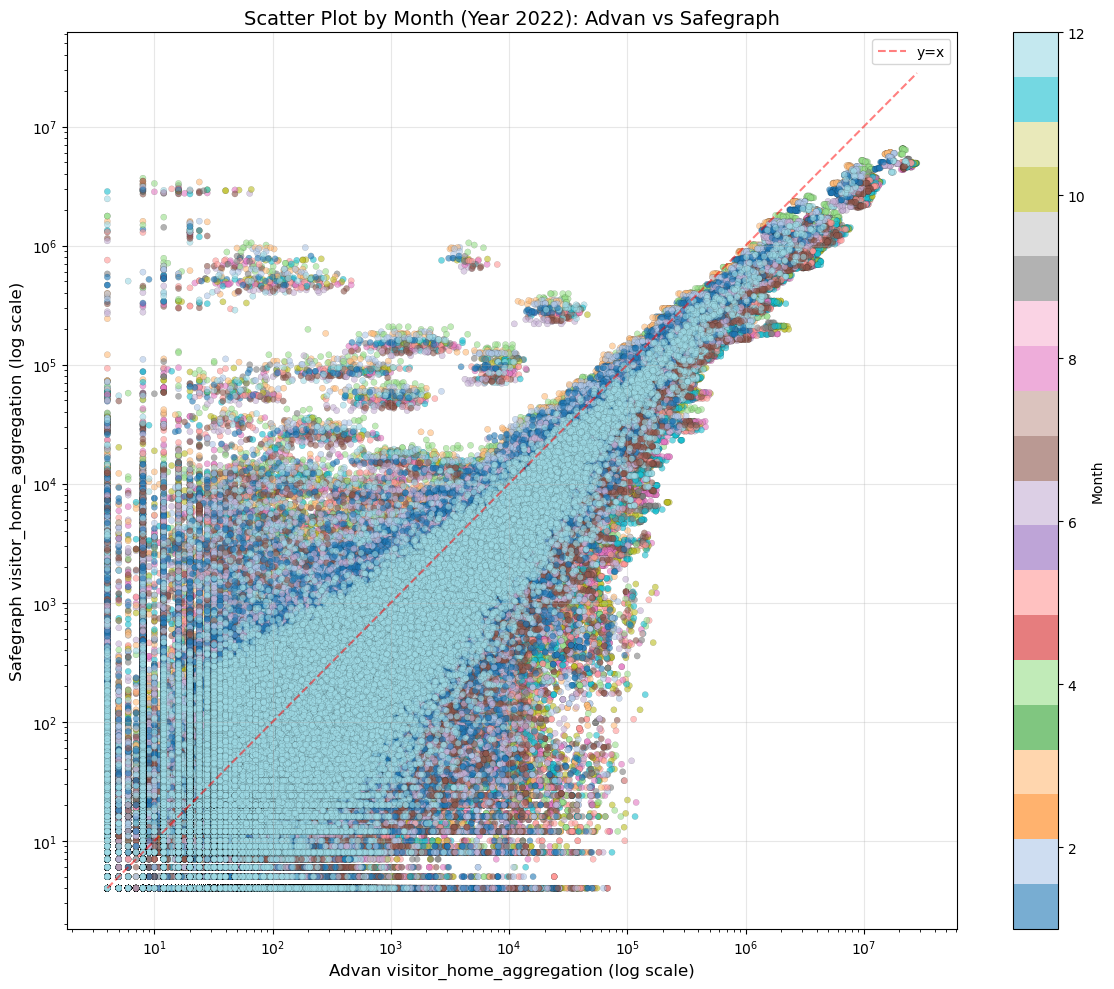


Correlation by month:
  Month 1: 0.9606
  Month 2: 0.9616
  Month 3: 0.9573
  Month 4: 0.9545
  Month 5: 0.9523
  Month 6: 0.9437
  Month 7: 0.9492
  Month 8: 0.9512
  Month 9: 0.9484
  Month 10: 0.9475
  Month 11: 0.9453
  Month 12: 0.9399
CPU times: user 6min 15s, sys: 56.7 s, total: 7min 11s
Wall time: 6min 54s


In [ ]:
%%time
# 1. Scatter plot colored by month to check time patterns
plot_scatter_by_time(merged_df_2022, year=2022)



In [ ]:
merged_df_2022['cbsa_orig'] = merged_df_2022['cbsa_orig'].astype(str)
merged_df_2022['cbsa_dest'] = merged_df_2022['cbsa_dest'].astype(str)

merged_df_2022.info()


/local/ipykernel_3000026/1192152220.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_2022['cbsa_orig'] = merged_df_2022['cbsa_orig'].astype(str)
/local/ipykernel_3000026/1192152220.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_2022['cbsa_dest'] = merged_df_2022['cbsa_dest'].astype(str)


<class 'pandas.core.frame.DataFrame'>
Index: 19943338 entries, 0 to 19943337
Data columns (total 14 columns):
 #   Column                              Dtype  
---  ------                              -----  
 0   date_range_start                    object 
 1   date_range_end                      object 
 2   cbsa_orig                           object 
 3   cbsa_dest                           object 
 4   visitor_home_aggregation_advan      int64  
 5   visitor_home_aggregation_safegraph  int64  
 6   VISITS_DAY_0                        int64  
 7   VISITS_DAY_1                        int64  
 8   VISITS_DAY_2                        int64  
 9   VISITS_DAY_3                        int64  
 10  VISITS_DAY_4                        int64  
 11  VISITS_DAY_5                        int64  
 12  VISITS_DAY_6                        int64  
 13  ratio                               float64
dtypes: float64(1), int64(9), object(4)
memory usage: 2.2+ GB


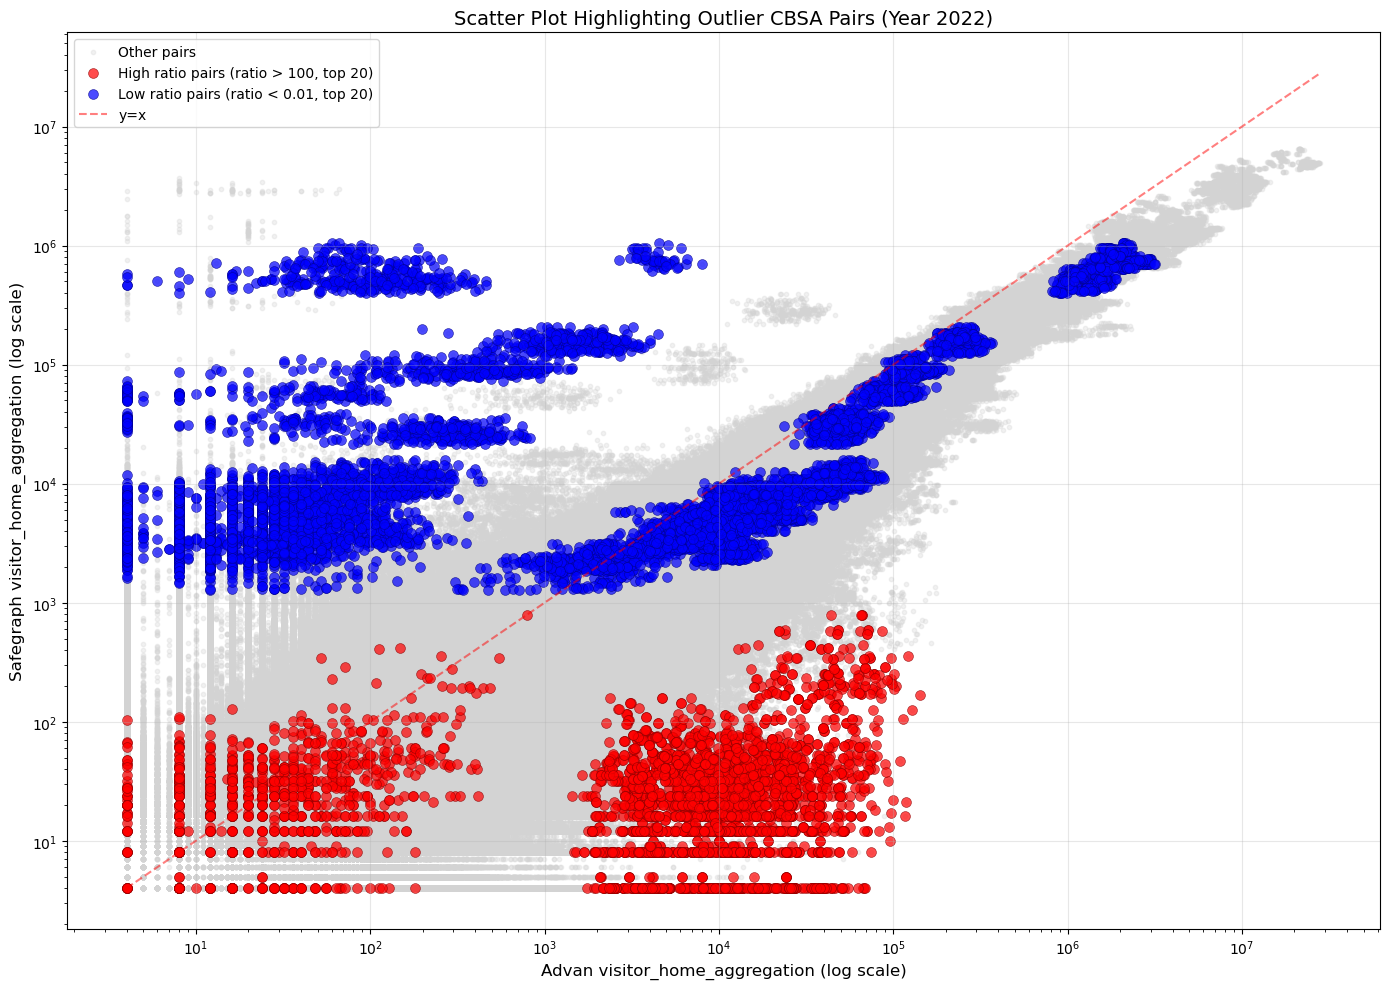


Top high ratio pairs (advan >> safegraph):
  31340 -> 14380: 237 records, mean ratio: 1002.98
  40220 -> 14380: 241 records, mean ratio: 2339.14
  11700 -> 40220: 254 records, mean ratio: 754.92
  48200 -> 14380: 223 records, mean ratio: 552.98
  11700 -> 14380: 260 records, mean ratio: 206.84
  13980 -> 14380: 229 records, mean ratio: 353.33
  35900 -> 40220: 187 records, mean ratio: 414.81
  25420 -> 27740: 153 records, mean ratio: 2833.92
  14380 -> 40220: 182 records, mean ratio: 655.06
  10900 -> 28700: 230 records, mean ratio: 503.33

Top low ratio pairs (safegraph >> advan):
  28940 -> 28940: 508 records, mean ratio: 1.3101
  43780 -> 43780: 519 records, mean ratio: 0.7488
  12060 -> 29300: 475 records, mean ratio: 1.1293
  10760 -> 12220: 519 records, mean ratio: 1.7362
  29300 -> 17980: 492 records, mean ratio: 2.3051
  12060 -> 17980: 421 records, mean ratio: 1.1166
  21060 -> 21060: 403 records, mean ratio: 1.1262
  19140 -> 16860: 516 records, mean ratio: 2.0225
  17980 ->

In [ ]:
%%time
# 2. Scatter plot highlighting top outlier CBSA pairs
plot_scatter_by_cbsa_pair(merged_df_2022, year=2022, top_n=20)



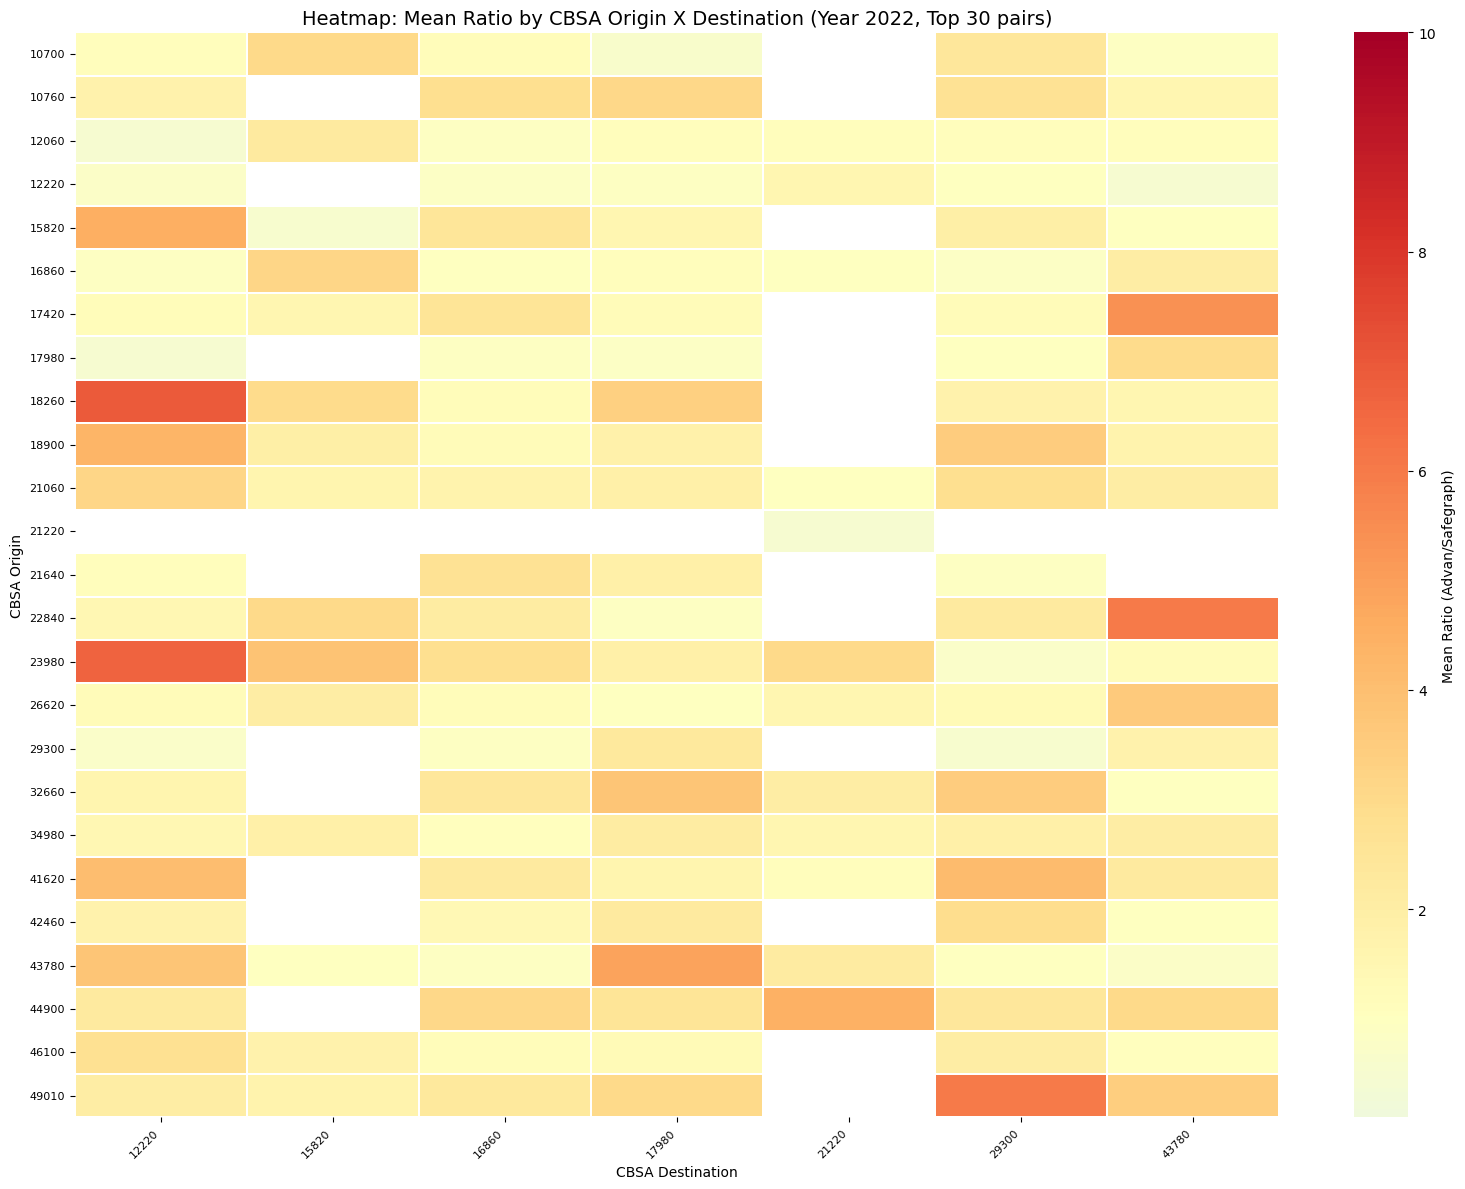

CPU times: user 10.7 s, sys: 16.2 s, total: 26.9 s
Wall time: 33 s


In [ ]:
%%time
# 3. Heatmap of ratios by CBSA origin X destination
plot_ratio_heatmap_by_cbsa(merged_df_2022, year=2022, top_n=30)



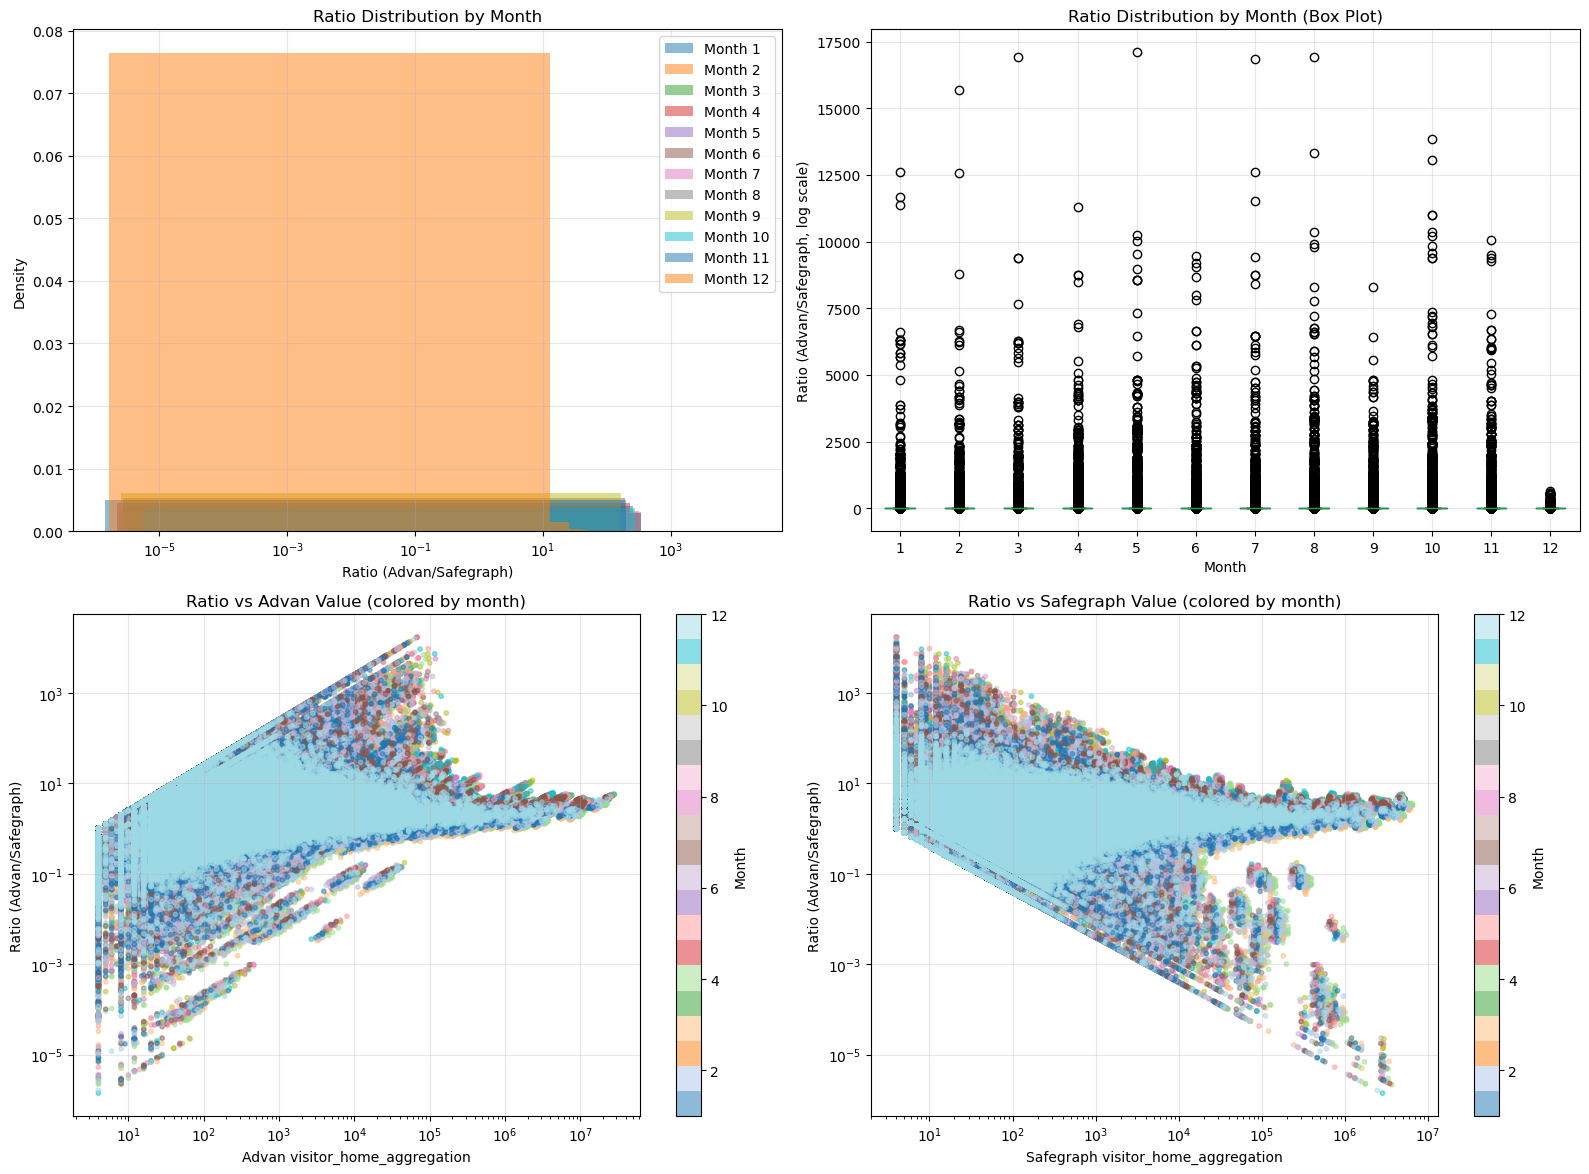


Ratio statistics by month:
           count      mean        std       min       25%       50%       75%  \
month                                                                           
1      1338640.0  2.827569  32.874625  0.000003  0.500000  1.020408  2.311041   
2      1183103.0  2.667887  35.660474  0.000003  0.486486  1.000000  2.142857   
3      1362080.0  2.357759  32.831979  0.000002  0.422524  0.963855  2.000000   
4      1475634.0  2.843357  32.440415  0.000002  0.500000  1.049180  2.292625   
5      2012490.0  3.323873  35.065977  0.000003  0.634146  1.345455  3.000000   
6      1776186.0  2.908646  31.150773  0.000003  0.558140  1.189392  2.545455   
7      2035644.0  3.246429  32.263239  0.000002  0.666667  1.400000  3.000000   
8      2222388.0  3.522893  34.710888  0.000004  0.666667  1.479182  3.000000   
9      1539053.0  3.264777  26.512412  0.000002  0.636364  1.349333  3.000000   
10     1923364.0  3.512252  39.644824  0.000006  0.666667  1.458333  3.000000   


In [ ]:
%%time
# 4. Ratio distributions across different dimensions
plot_ratio_distribution_by_dimension(merged_df_2022, year=2022)



/local/ipykernel_3000026/497327314.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orig_outlier_pct = df[df['cbsa_orig'].isin(top_orig)].groupby('cbsa_orig').apply(
/local/ipykernel_3000026/497327314.py:107: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


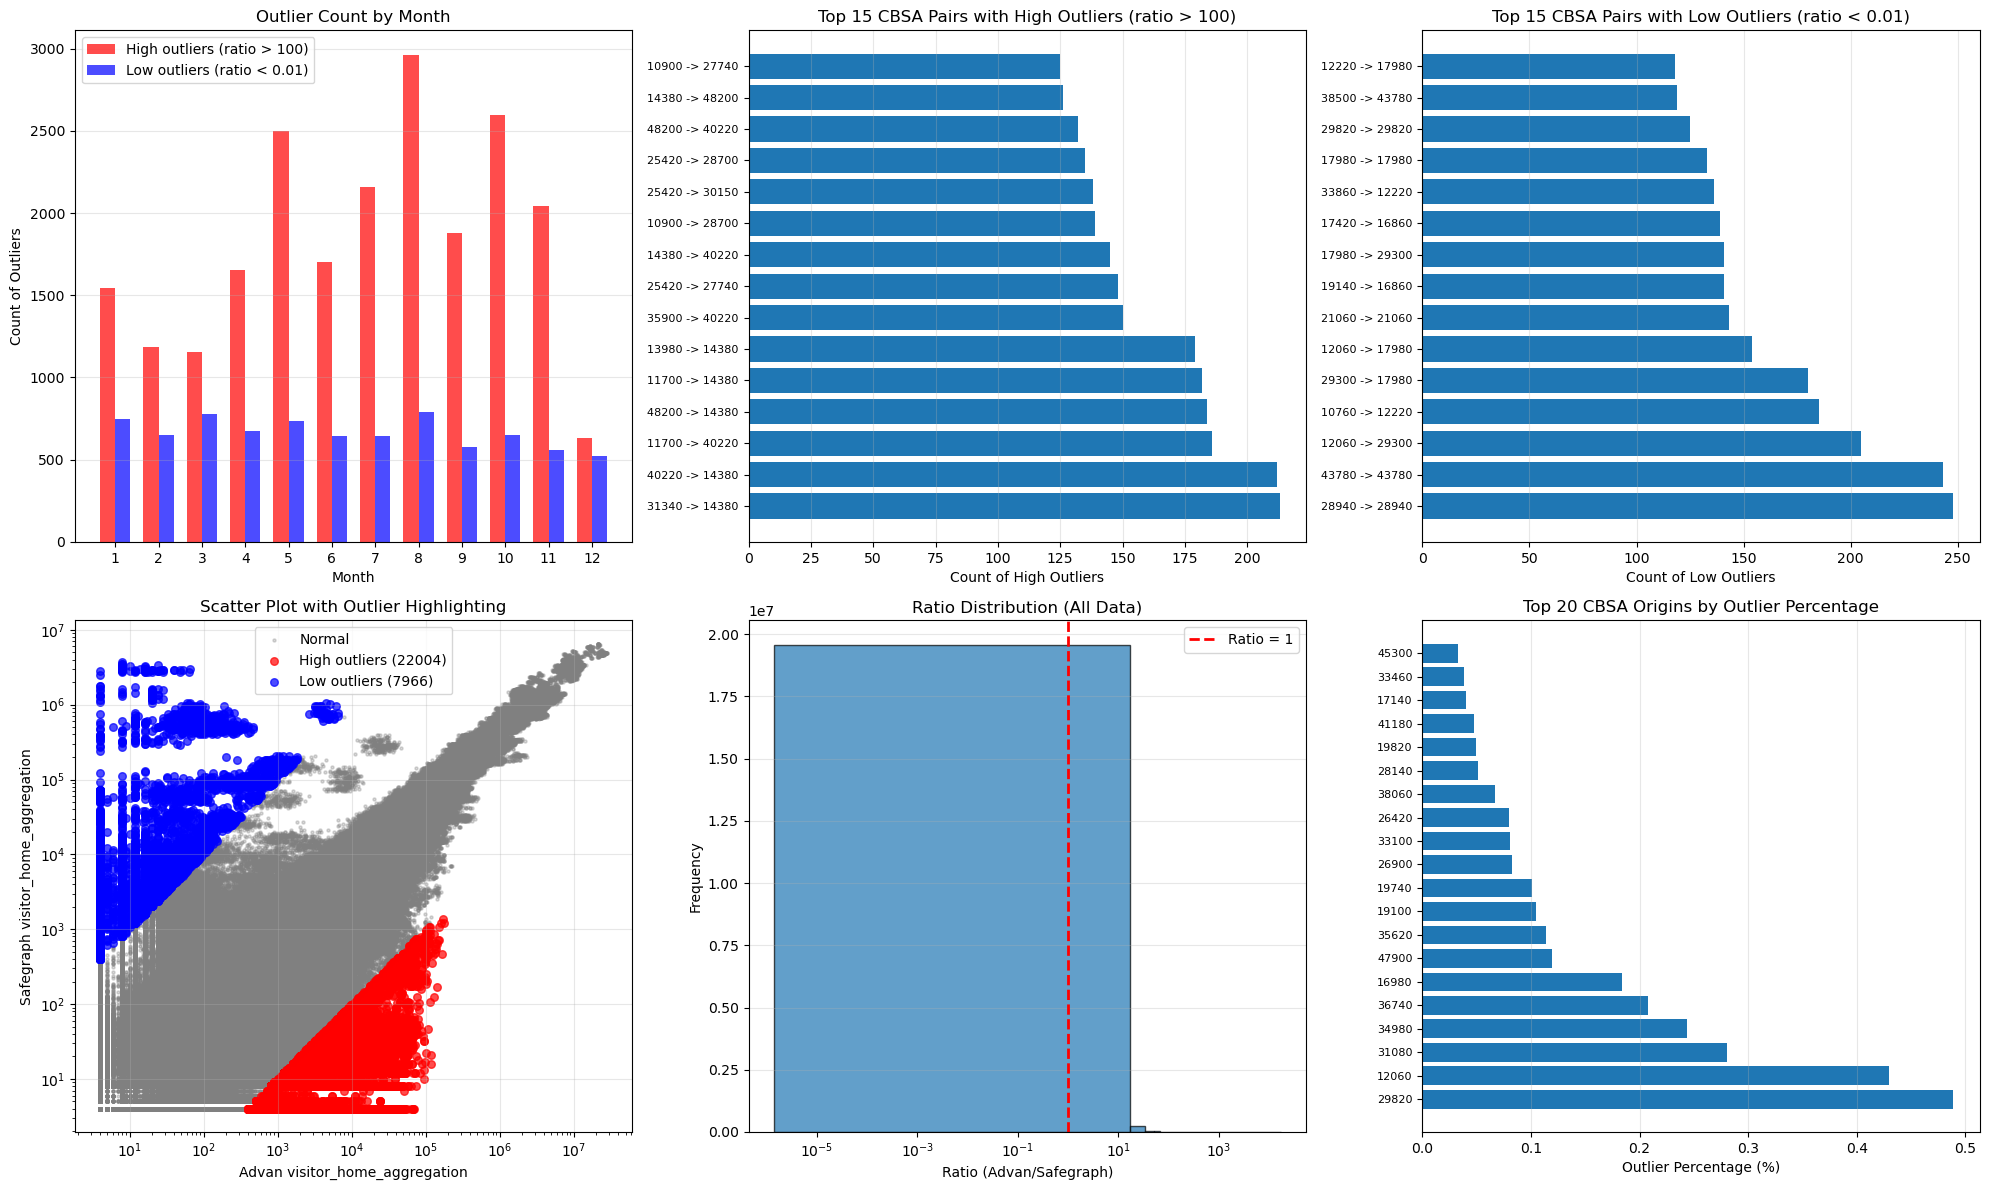


Outlier Summary (Year 2022):
  Total records: 19943338
  High outliers (ratio > 100): 22004 (0.11%)
  Low outliers (ratio < 0.01): 7966 (0.04%)
  Normal records: 19913368
CPU times: user 7min 17s, sys: 1min 54s, total: 9min 12s
Wall time: 9min 18s


In [ ]:
%%time
# 5. Comprehensive outlier analysis
plot_outlier_analysis(merged_df_2022, year=2022)
